In [1]:
# ── CONFIGURE THIS ──────────────────────────────────────────────────────────
BASE_URL = "http://154.57.164.74:32035"   # <-- paste your instance IP:port
# ────────────────────────────────────────────────────────────────────────────

import os, io, base64, numpy as np, requests, torch, torch.nn as nn
import torch.nn.functional as F
from PIL import Image

MNIST_MEAN, MNIST_STD = 0.1307, 0.3081

def x01_from_b64_png(b64: str) -> np.ndarray:
    """Convert base64 PNG to [0,1] numpy array."""
    raw = base64.b64decode(b64)
    img = Image.open(io.BytesIO(raw)).convert("L")
    if img.size != (28, 28):
        raise ValueError("Expected 28x28 PNG")
    x = np.asarray(img, dtype=np.float32) / 255.0
    return np.clip(x, 0.0, 1.0)

def b64_png_from_x01(x2d: np.ndarray) -> str:
    """Convert [0,1] array to base64 PNG."""
    x255 = np.clip((x2d * 255.0).round(), 0, 255).astype(np.uint8)
    img = Image.fromarray(x255, mode="L")
    buf = io.BytesIO()
    img.save(buf, format="PNG", optimize=True)
    return base64.b64encode(buf.getvalue()).decode("ascii")

def linf(a: np.ndarray, b: np.ndarray) -> float:
    """Compute L_inf distance between two arrays."""
    return float(np.max(np.abs(a - b)))

print("Helpers loaded.")

Helpers loaded.


In [2]:
ch  = requests.get(f"{BASE_URL}/challenge", timeout=10).json()
x   = x01_from_b64_png(ch["image_b64"])
lab = int(ch["label"])
target = int(ch["target"])
eps = float(ch["l2_threshold"])  # was ch["epsilon"]
res = requests.post(f"{BASE_URL}/predict",
                    json={"image_b64": b64_png_from_x01(x)},
                    timeout=10).json()
print({"baseline_label": lab, "target": target, "server_pred": res["pred"], "l2_threshold": eps})
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

{'baseline_label': 4, 'target': 6, 'server_pred': 4, 'l2_threshold': 0.75}


In [3]:
# ── Model architecture ────────────────────────────────────────────────────────
class SimpleClassifier(nn.Module):
    def __init__(self):
        super().__init__()
        self.conv1    = nn.Conv2d(1, 32, 3, 1)
        self.conv2    = nn.Conv2d(32, 64, 3, 1)
        self.dropout1 = nn.Dropout(0.25)
        self.dropout2 = nn.Dropout(0.5)
        self.fc1      = nn.Linear(9216, 128)
        self.fc2      = nn.Linear(128, 10)

    def forward(self, x01: torch.Tensor) -> torch.Tensor:
        """Forward pass with internal normalization.
        Args:
            x01: Input tensor in [0,1] with shape (N, 1, 28, 28)
        Returns:
            Log-probabilities with shape (N, 10)
        """
        x = (x01 - MNIST_MEAN) / MNIST_STD
        x = torch.relu(self.conv1(x))
        x = torch.relu(self.conv2(x))
        x = torch.max_pool2d(x, 2)
        x = self.dropout1(x)
        x = torch.flatten(x, 1)
        x = torch.relu(self.fc1(x))
        x = self.dropout2(x)
        x = self.fc2(x)
        return torch.log_softmax(x, dim=1)

# Download and load weights
wt = requests.get(f"{BASE_URL}/weights", timeout=10).content
open("deepfool_weights.pth", "wb").write(wt)

model = SimpleClassifier().eval()
state = torch.load("deepfool_weights.pth", map_location=torch.device("cpu"))
model.load_state_dict(state)

# Verify model works locally
x_tensor   = torch.from_numpy(x[None, None, ...]).float()
logits     = model(x_tensor)
local_pred = int(torch.argmax(logits, dim=1).item())
print(f"Local prediction: {local_pred}, should match server: {res['pred']}")

Local prediction: 4, should match server: 4


In [4]:
# ── Test server validation (expect 400 Not misclassified) ─────────────────────
bad = requests.post(f"{BASE_URL}/submit",
                    json={"image_b64": b64_png_from_x01(x)},
                    timeout=10)
print(bad.status_code, bad.text)  # expected: 400 with "Not misclassified"

400 {"detail":"Wrong target: predicted 4, need 6"}


In [15]:
def deepfool_targeted(image: torch.Tensor,
             net: nn.Module,
             target_class: int,
             overshoot: float = 0.02,
             max_iter: int = 50,
             device: str = 'cuda') -> tuple[torch.Tensor, int, int, int, torch.Tensor]:

    image = image.to(device)
    net = net.to(device)

    f_image = net(image).data.cpu().numpy().flatten()
    I = f_image.argsort()[::-1]
    label = I[0]

    input_shape = image.shape
    pert_image = image.clone()
    r_tot = torch.zeros(input_shape).to(device)
    loop_i = 0

    while loop_i < max_iter:
        x = pert_image.clone().requires_grad_(True)
        fs = net(x)

        k_i = fs.data.cpu().numpy().flatten().argsort()[::-1][0]

        if k_i == target_class:
            break

        # Update current label each iteration
        label = k_i

        if x.grad is not None:
            x.grad.zero_()
        fs[0, target_class].backward(retain_graph=True)
        grad_target = x.grad.data.clone()

        if x.grad is not None:
            x.grad.zero_()
        fs[0, label].backward(retain_graph=True)
        grad_label = x.grad.data.clone()

        w = grad_target - grad_label
        f_k = (fs[0, target_class] - fs[0, label]).data.cpu().numpy()
        pert = abs(f_k) / (torch.norm(w.flatten()) + 1e-10)

        r_i = (pert + 1e-4) * w / (torch.norm(w.flatten()) + 1e-10)
        r_tot = r_tot + r_i

        pert_image = torch.clamp(image + (1 + overshoot) * r_tot, 0.0, 1.0)
        loop_i += 1

    return r_tot, loop_i, label, k_i, pert_image

In [16]:

# Prepare tensor
image = torch.from_numpy(x[None, None, ...]).float().to(device)

# Execute targeted DeepFool
r_total, iterations, orig_label, pert_label, pert_image = deepfool_targeted(
    image, model, target_class=target, overshoot=0.02, max_iter=50, device=device
)
print(f"Attack: {orig_label} → {pert_label} in {iterations} iterations")

# Verify locally
with torch.no_grad():
    local_logits = model(pert_image)
    local_pred   = int(torch.argmax(local_logits, dim=1).item())
    local_conf   = F.softmax(local_logits, dim=1).max().item()
print(f"Local perturbed pred: {local_pred} (confidence: {local_conf:.3f})")

Attack: 4 → 6 in 8 iterations
Local perturbed pred: 6 (confidence: 0.377)


In [17]:
x_adv = pert_image.squeeze().cpu().detach().numpy().clip(0, 1)

# Simulate what server receives after PNG roundtrip
x_adv_quantized = np.round(x_adv * 255.0) / 255.0

# Check if attack survives quantization
x_tensor_q = torch.from_numpy(x_adv_quantized[None, None, ...]).float()
with torch.no_grad():
    pred_q = int(torch.argmax(model(x_tensor_q), dim=1).item())
print(f"Post-quantization local pred: {pred_q}")  # if still 4, attack dies in PNG

l2_dist = float(np.linalg.norm(x_adv_quantized - x))
print(f"L2 after quantization: {l2_dist:.4f}")

Post-quantization local pred: 4
L2 after quantization: 0.7179


In [19]:
# After the loop finds overshoot=0.5 works (pred_q=6 but l2 too large)
x_adv = pert_image.squeeze().cpu().detach().numpy().clip(0, 1)

# Project perturbation onto L2 ball with small safety margin
delta = x_adv - x
l2_raw = float(np.linalg.norm(delta))
print(f"Raw L2: {l2_raw:.4f}")

# Scale down delta to fit within budget (use 0.99x for safety margin)
if l2_raw > eps:
    delta = delta * (eps * 0.99) / l2_raw

x_adv_projected = np.clip(x + delta, 0, 1)
x_adv_q = np.round(x_adv_projected * 255.0) / 255.0

# Verify
x_t = torch.from_numpy(x_adv_q[None, None, ...]).float()
with torch.no_grad():
    pred_q = int(torch.argmax(model(x_t)).item())
l2_final = float(np.linalg.norm(x_adv_q - x))
print(f"After projection: pred_q={pred_q}, l2={l2_final:.4f} (limit={eps})")

if pred_q == target and l2_final <= eps:
    result = requests.post(f"{BASE_URL}/submit",
                           json={"image_b64": b64_png_from_x01(x_adv_q)},
                           timeout=10).json()
    print(result)

Raw L2: 0.7699
After projection: pred_q=6, l2=0.7420 (limit=0.75)
{'ok': True, 'flag': 'HTB{d33pf00l_f00lz}', 'pred': 6, 'target': 6, 'l2': 0.7419541478157043}


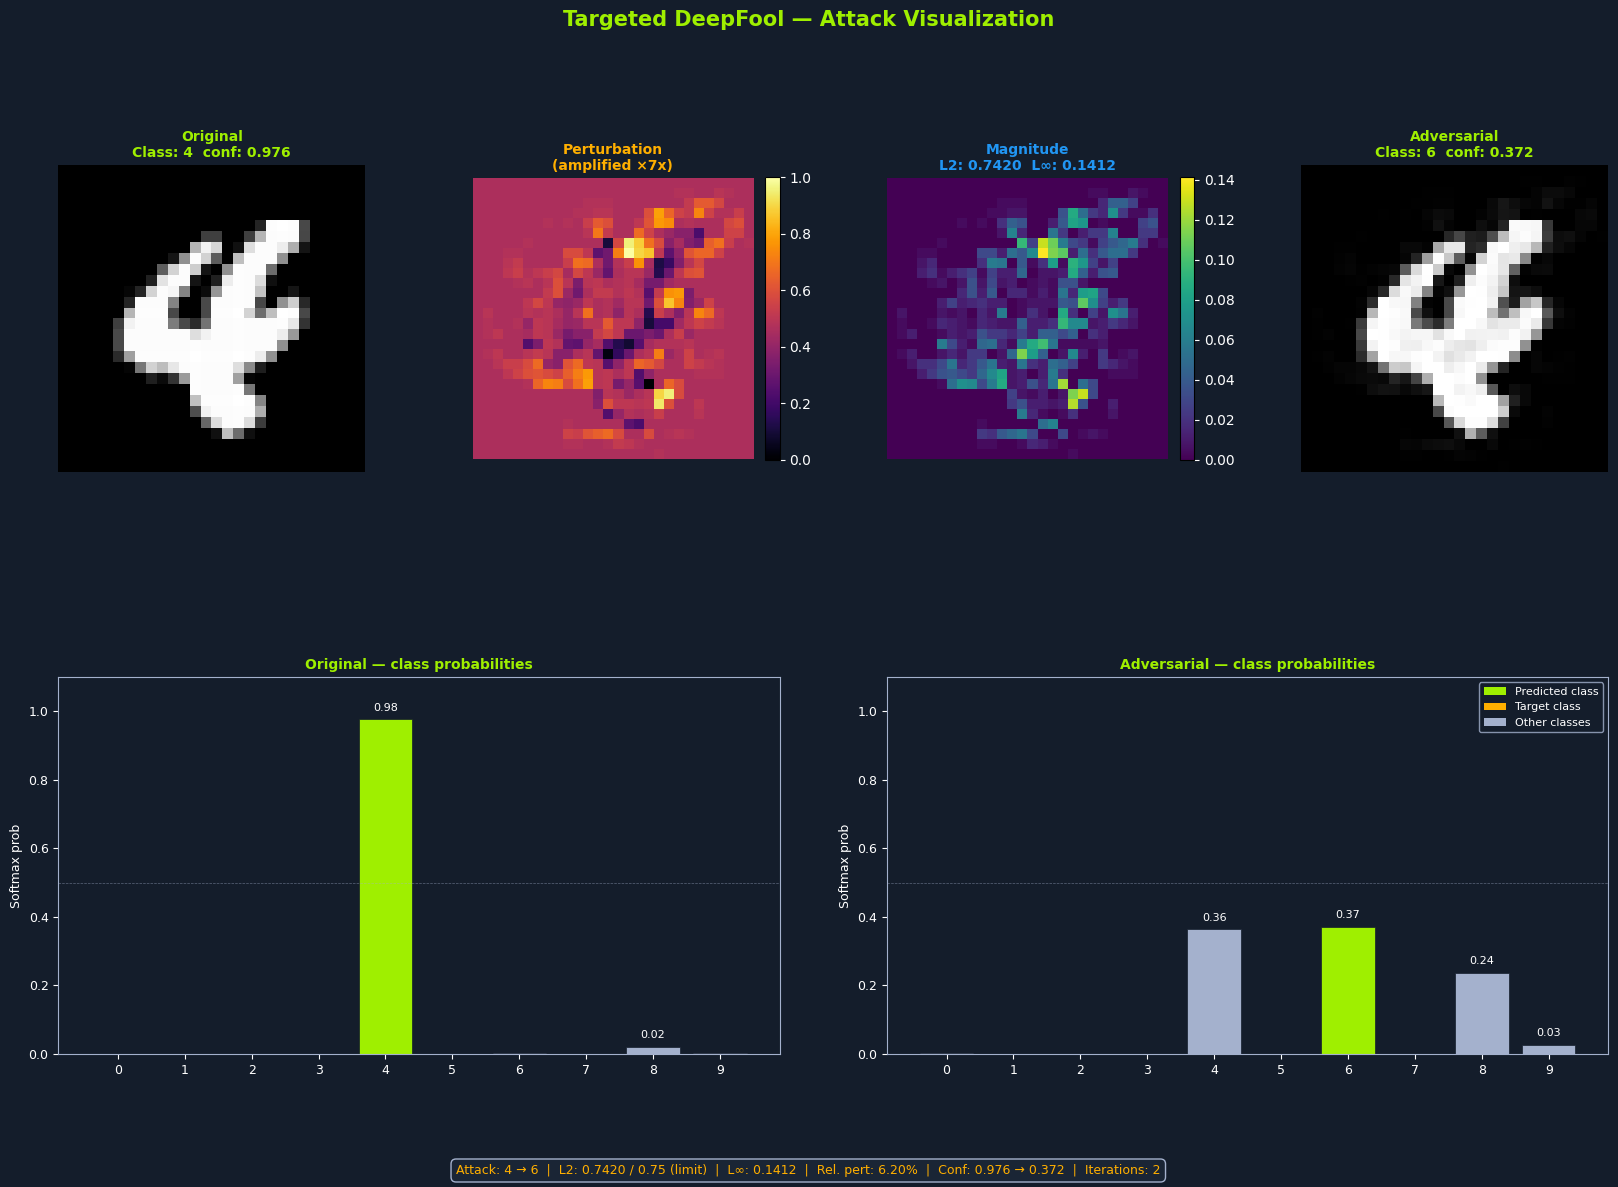

Saved to deepfool_targeted_viz.png


In [22]:
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
import numpy as np
import torch.nn.functional as F

HTB_GREEN = "#9fef00"
NODE_BLACK = "#141d2b"
HACKER_GREY = "#a4b1cd"
WHITE = "#ffffff"
AZURE = "#2196f3"
NUGGET_YELLOW = "#ffaf00"
MALWARE_RED = "#ff3e3e"
VIVID_PURPLE = "#9b59b6"

# ── Recompute everything we need ─────────────────────────────────────────────
x_adv_final = x_adv_q  # your final projected+quantized adversarial image (28x28)
x_orig      = x        # original image (28x28)
delta       = x_adv_final - x_orig  # raw perturbation

# Confidence vectors
with torch.no_grad():
    orig_logits = model(torch.from_numpy(x_orig[None,None,...]).float())
    adv_logits  = model(torch.from_numpy(x_adv_final[None,None,...]).float())

orig_probs = F.softmax(orig_logits, dim=1).squeeze().numpy()
adv_probs  = F.softmax(adv_logits,  dim=1).squeeze().numpy()
orig_conf  = orig_probs.max()
adv_conf   = adv_probs.max()
orig_pred  = orig_probs.argmax()
adv_pred   = adv_probs.argmax()

l2_dist    = float(np.linalg.norm(delta))
linf_dist  = float(np.abs(delta).max())
rel_pert   = l2_dist / float(np.linalg.norm(x_orig))

# Amplified perturbation for display
pert_display = delta - delta.min()
if pert_display.max() > 0:
    pert_display = pert_display / pert_display.max()

# ── Figure layout ─────────────────────────────────────────────────────────────
fig = plt.figure(figsize=(20, 12), facecolor=NODE_BLACK)
gs  = gridspec.GridSpec(2, 4, figure=fig, hspace=0.45, wspace=0.35)

ax_orig  = fig.add_subplot(gs[0, 0])
ax_pert  = fig.add_subplot(gs[0, 1])
ax_mag   = fig.add_subplot(gs[0, 2])
ax_adv   = fig.add_subplot(gs[0, 3])
ax_obar  = fig.add_subplot(gs[1, 0:2])
ax_abar  = fig.add_subplot(gs[1, 2:4])

for ax in fig.get_axes():
    ax.set_facecolor(NODE_BLACK)
    for spine in ax.spines.values():
        spine.set_edgecolor(HACKER_GREY)
    ax.tick_params(colors=WHITE, labelsize=9)

# ── Panel 1: Original ─────────────────────────────────────────────────────────
ax_orig.imshow(x_orig, cmap='gray', vmin=0, vmax=1)
ax_orig.set_title(f"Original\nClass: {orig_pred}  conf: {orig_conf:.3f}",
                  color=HTB_GREEN, fontweight='bold', fontsize=10)
ax_orig.axis('off')

# ── Panel 2: Perturbation (amplified) ────────────────────────────────────────
im_pert = ax_pert.imshow(pert_display, cmap='inferno', vmin=0, vmax=1)
ax_pert.set_title(f"Perturbation\n(amplified ×{1/max(np.abs(delta).max(),1e-8):.0f}x)",
                  color=NUGGET_YELLOW, fontweight='bold', fontsize=10)
ax_pert.axis('off')
plt.colorbar(im_pert, ax=ax_pert, fraction=0.046, pad=0.04).ax.tick_params(colors=WHITE)

# ── Panel 3: Magnitude heatmap ────────────────────────────────────────────────
im_mag = ax_mag.imshow(np.abs(delta), cmap='viridis')
ax_mag.set_title(f"Magnitude\nL2: {l2_dist:.4f}  L∞: {linf_dist:.4f}",
                 color=AZURE, fontweight='bold', fontsize=10)
ax_mag.axis('off')
plt.colorbar(im_mag, ax=ax_mag, fraction=0.046, pad=0.04).ax.tick_params(colors=WHITE)

# ── Panel 4: Adversarial ──────────────────────────────────────────────────────
ax_adv.imshow(x_adv_final, cmap='gray', vmin=0, vmax=1)
ax_adv.set_title(f"Adversarial\nClass: {adv_pred}  conf: {adv_conf:.3f}",
                 color=HTB_GREEN if adv_pred == target else MALWARE_RED,
                 fontweight='bold', fontsize=10)
ax_adv.axis('off')

# ── Panel 5: Original class probabilities ────────────────────────────────────
colors_orig = [HTB_GREEN if i == orig_pred else HACKER_GREY for i in range(10)]
bars_o = ax_obar.bar(range(10), orig_probs, color=colors_orig, edgecolor=NODE_BLACK, linewidth=0.5)
ax_obar.set_title("Original — class probabilities", color=HTB_GREEN, fontsize=10, fontweight='bold')
ax_obar.set_xticks(range(10))
ax_obar.set_xticklabels([str(i) for i in range(10)], color=WHITE)
ax_obar.set_ylim(0, 1.1)
ax_obar.set_ylabel("Softmax prob", color=WHITE, fontsize=9)
ax_obar.axhline(0.5, color=HACKER_GREY, linewidth=0.5, linestyle='--', alpha=0.5)
for bar, prob in zip(bars_o, orig_probs):
    if prob > 0.02:
        ax_obar.text(bar.get_x() + bar.get_width()/2, prob + 0.02,
                     f'{prob:.2f}', ha='center', va='bottom', color=WHITE, fontsize=8)

# ── Panel 6: Adversarial class probabilities ─────────────────────────────────
colors_adv = [HTB_GREEN if i == adv_pred else (NUGGET_YELLOW if i == target else HACKER_GREY) for i in range(10)]
bars_a = ax_abar.bar(range(10), adv_probs, color=colors_adv, edgecolor=NODE_BLACK, linewidth=0.5)
ax_abar.set_title("Adversarial — class probabilities", color=HTB_GREEN, fontsize=10, fontweight='bold')
ax_abar.set_xticks(range(10))
ax_abar.set_xticklabels([str(i) for i in range(10)], color=WHITE)
ax_abar.set_ylim(0, 1.1)
ax_abar.set_ylabel("Softmax prob", color=WHITE, fontsize=9)
ax_abar.axhline(0.5, color=HACKER_GREY, linewidth=0.5, linestyle='--', alpha=0.5)
for bar, prob in zip(bars_a, adv_probs):
    if prob > 0.02:
        ax_abar.text(bar.get_x() + bar.get_width()/2, prob + 0.02,
                     f'{prob:.2f}', ha='center', va='bottom', color=WHITE, fontsize=8)

# ── Legend for bar colors ─────────────────────────────────────────────────────
from matplotlib.patches import Patch
legend_elements = [
    Patch(facecolor=HTB_GREEN,     label='Predicted class'),
    Patch(facecolor=NUGGET_YELLOW, label='Target class'),
    Patch(facecolor=HACKER_GREY,   label='Other classes'),
]
ax_abar.legend(handles=legend_elements, loc='upper right',
               facecolor=NODE_BLACK, edgecolor=HACKER_GREY,
               labelcolor=WHITE, fontsize=8)

# ── Global metrics footer ─────────────────────────────────────────────────────
metrics = (
    f"Attack: {orig_pred} → {adv_pred}  |  "
    f"L2: {l2_dist:.4f} / {eps:.2f} (limit)  |  "
    f"L∞: {linf_dist:.4f}  |  "
    f"Rel. pert: {rel_pert:.2%}  |  "
    f"Conf: {orig_conf:.3f} → {adv_conf:.3f}  |  "
    f"Iterations: {iterations}"
)
fig.text(0.5, 0.01, metrics, ha='center', fontsize=9,
         color=NUGGET_YELLOW,
         bbox=dict(boxstyle='round,pad=0.4', facecolor='#1a2535', edgecolor=HACKER_GREY))

fig.suptitle("Targeted DeepFool — Attack Visualization", fontsize=15,
             color=HTB_GREEN, fontweight='bold', y=0.98)

plt.savefig("deepfool_targeted_viz.png", dpi=150, bbox_inches='tight', facecolor=NODE_BLACK)
plt.show()
print("Saved to deepfool_targeted_viz.png")